# 00 · 시작하기 — 환경 점검 & 대사체 전처리 데모

이 노트북은 `Python (marine-metab)` 커널로 실행하세요.
합성 데이터로 전처리 파이프라인 → PCA 까지 확인합니다.

In [1]:
import sys
from pathlib import Path

# 프로젝트 src 를 import 경로에 추가
sys.path.append(str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import data_processing as dp

print('Python', sys.version.split()[0])
print('pandas', pd.__version__, '| numpy', np.__version__)
print('프로젝트 루트:', dp.ROOT)

Python 3.12.13
pandas 3.0.3 | numpy 2.5.1
프로젝트 루트: C:\Users\RYU\projects\marine-metabolomics


## 합성 대사체 데이터 생성
실제 데이터가 준비되면 이 셀을 `dp.load_feature_table('../data/raw/...')` 로 교체하세요.

In [2]:
rng = np.random.default_rng(42)
n_samples, n_features = 30, 200

# 두 채집지(site A/B) — 대사체 프로파일이 조금 다르게
site = np.array(['A'] * 15 + ['B'] * 15)
base = rng.lognormal(mean=8, sigma=1.0, size=(n_samples, n_features))
shift = np.where(site[:, None] == 'B', rng.lognormal(8.5, 1.0, (n_samples, n_features)), 0)
X = base + shift * (rng.random((n_samples, n_features)) < 0.3)

feat = pd.DataFrame(X, index=[f'S{i:03d}' for i in range(n_samples)],
                    columns=[f'M{j:03d}' for j in range(n_features)])
# 결측 일부 삽입
mask = rng.random(feat.shape) < 0.05
feat = feat.mask(mask)
feat.iloc[:3, :4]

,M000,M001,M002,M003
S000,4042.898159,1053.650304,6313.536107,7635.507735
S001,4177.944043,12179.163507,3263.595912,5675.641033
S002,2490.873139,3629.231136,6771.842432,2010.741478


In [3]:
# 표준 전처리: 결측필터 → 대치 → log2 → Pareto 스케일
Xp = dp.preprocess(feat)
print('전처리 후 shape:', Xp.shape)
Xp.iloc[:3, :4]

전처리 후 shape: (30, 200)


,M000,M001,M002,M003
S000,0.250312,-1.454964,0.627357,0.725114
S001,0.290793,1.404468,-0.280931,0.404576
S002,-0.346341,-0.010303,0.723823,-0.716581


C:\Users\RYU\AppData\Local\Temp\ipykernel_840\403075220.py:15: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RYU\AppData\Local\Temp\ipykernel_840\403075220.py:15: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RYU\AppData\Local\Temp\ipykernel_840\403075220.py:15: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RYU\AppData\Local\Temp\ipykernel_840\403075220.py:15: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RYU\AppData\Local\Temp\ipykernel_840\403075220.py:15: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\RYU\AppData\Local\Temp\ipykernel_840\403075220.py:15: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  plt.

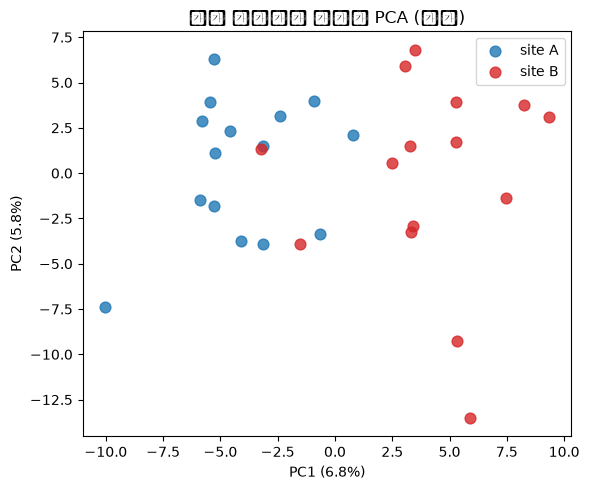

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
scores = pca.fit_transform(Xp.values)
ev = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(6, 5))
for s, c in zip(['A', 'B'], ['#1f77b4', '#d62728']):
    m = site == s
    ax.scatter(scores[m, 0], scores[m, 1], label=f'site {s}', s=60, alpha=0.8, color=c)
ax.set_xlabel(f'PC1 ({ev[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({ev[1]:.1f}%)')
ax.set_title('연안 자생식물 대사체 PCA (데모)')
ax.legend()
plt.tight_layout()
plt.show()

채집지 A/B 가 PC1 을 따라 분리되면 파이프라인이 정상 동작하는 것입니다.

**다음 단계**: `data/raw/` 에 실제 대사체 정량 테이블, `data/metadata/` 에 환경·샘플 메타데이터를 넣고
위 합성 데이터 부분을 실제 로드로 교체하세요.